In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("../")
)

from src.market_data import download_prices

[*********************100%***********************]  4 of 4 completed


In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "META",
    "GOOGL",
    "TSLA",
    "JPM",
    "BAC",
    "XOM",
    "CVX",
    "JNJ",
    "PFE",
    "KO",
    "PEP",
    "WMT",
    "COST",
    "V",
    "MA",
    "UNH",
    "HD",
    "NKE",
    "DIS",
    "SPY"
]

In [3]:
prices = download_prices(
    tickers,
    "2020-01-01",
    "2025-01-01"
)

[*********************100%***********************]  24 of 24 completed


In [4]:
prices.to_csv(
    "../data/raw/prices.csv"
)

In [5]:
from src.returns import calculate_returns

In [6]:
returns = calculate_returns(
    prices
)

In [7]:
from src.factor_portfolios import (
    momentum_scores,
    select_top_assets
)

In [8]:
mom_scores = momentum_scores(
    prices
)

momentum_assets = select_top_assets(
    mom_scores,
    n=5
)

momentum_assets

['NVDA', 'WMT', 'META', 'TSLA', 'AMZN']

In [9]:
from src.factor_portfolios import volatility_scores


vol_scores = volatility_scores(
    returns
)


low_vol_assets = select_top_assets(
    vol_scores,
    n=5,
    ascending=True
)


low_vol_assets

['SPY', 'KO', 'JNJ', 'MA', 'PEP']

In [10]:
from src.factor_data import load_fama_french

factors = load_fama_french()

In [11]:
from src.value_factor import calculate_hml_exposures
hml_scores = calculate_hml_exposures(
    returns,
    factors
)

In [12]:
import pandas as pd


hml_series = pd.Series(
    hml_scores
)


value_assets = (
    hml_series
    .sort_values(
        ascending=False
    )
    .head(5)
    .index
    .tolist()
)


value_returns = (
    returns[value_assets]
    .mean(axis=1)
)

In [13]:
from src.factor_portfolios import (
    momentum_scores,
    volatility_scores,
    select_top_assets
)

In [14]:
mom_scores = momentum_scores(
    prices
)


momentum_assets = select_top_assets(
    mom_scores,
    n=5
)


momentum_returns = (
    returns[momentum_assets]
    .mean(axis=1)
)

In [15]:
market_returns = returns["SPY"]

In [16]:
from src.factor_portfolios import (
    volatility_scores,
    select_top_assets
)

In [17]:
vol_scores = volatility_scores(
    returns
)

vol_scores

Ticker
AAPL     0.226804
AMZN     0.280914
BAC      0.227268
COST     0.188412
CVX      0.192263
DIS      0.258239
GOOGL    0.280487
HD       0.204918
JNJ      0.151214
JPM      0.234935
KO       0.127938
MA       0.158717
META     0.364846
MSFT     0.199615
NKE      0.319928
NVDA     0.525033
PEP      0.163522
PFE      0.233549
SPY      0.125690
TSLA     0.634956
UNH      0.273008
V        0.168842
WMT      0.176869
XOM      0.192428
Name: 2024-12-31 00:00:00, dtype: float64

In [18]:
low_vol_assets = select_top_assets(
    vol_scores,
    n=5,
    ascending=True
)

low_vol_assets

['SPY', 'KO', 'JNJ', 'MA', 'PEP']

In [19]:
low_vol_returns = (
    returns[low_vol_assets]
    .mean(axis=1)
)

In [20]:
from src.factor_analysis import factor_performance_table


portfolios = {

    "Market (SPY)": market_returns,

    "Momentum": momentum_returns,

    "Value": value_returns,

    "Low Volatility": low_vol_returns

}

In [21]:
factor_table = factor_performance_table(
    portfolios
)

factor_table

,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Market (SPY),0.168348,0.209973,0.741232,-0.337173
1,Momentum,0.574251,0.331662,1.369431,-0.511419
2,Value,0.178829,0.277123,0.593870,-0.467003
3,Low Volatility,0.109193,0.189052,0.548285,-0.327701


In [22]:
from src.factor_charts import (
    cumulative_returns_chart,
    risk_return_scatter,
    sharpe_bar_chart
)

In [23]:
import importlib
import src.factor_charts

importlib.reload(src.factor_charts)

<module 'src.factor_charts' from 'd:\\Portfolio\\Factor Investing Lab — CAPM & Fama-French Framework\\src\\factor_charts.py'>

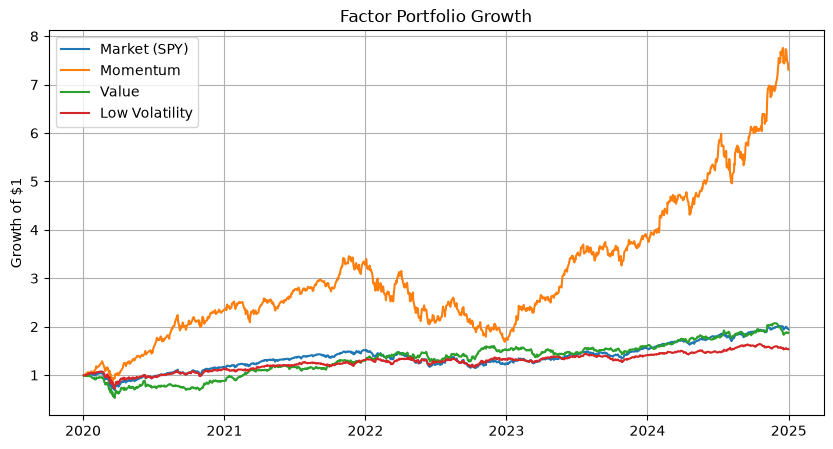

In [24]:
fig1 = cumulative_returns_chart(
    portfolios
)


fig1

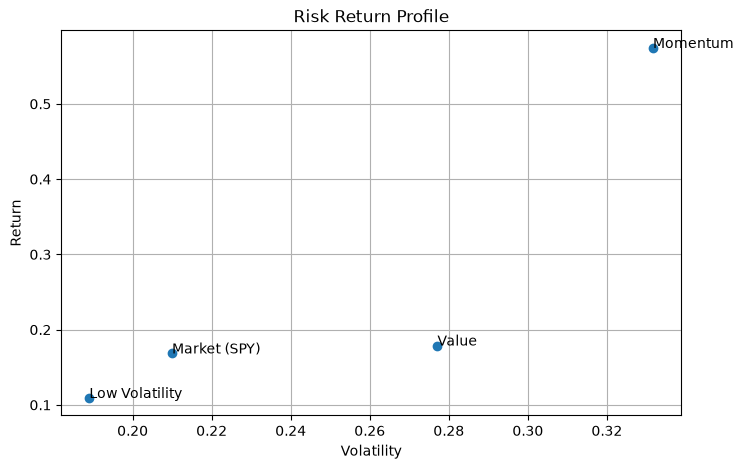

In [25]:
fig2 = risk_return_scatter(
    factor_table
)

fig2

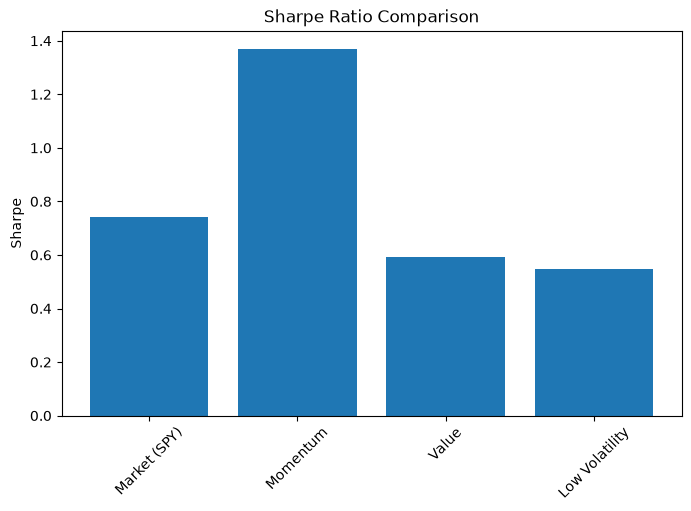

In [26]:
fig3 = sharpe_bar_chart(
    factor_table
)


fig3